# Word2Vec (Word Embedding)

- Word2Vec converts each word into a vector (list of numbers).
- Words appearing in similar contexts have similar meanings.

# 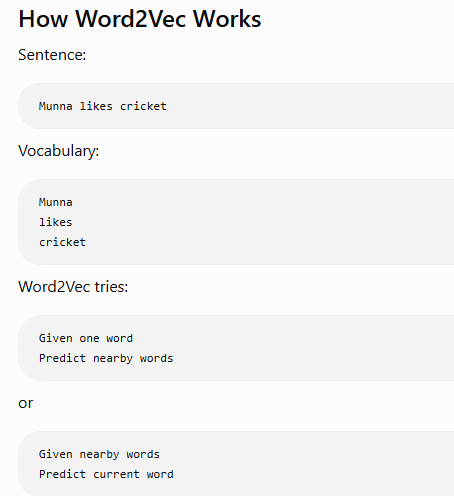

# 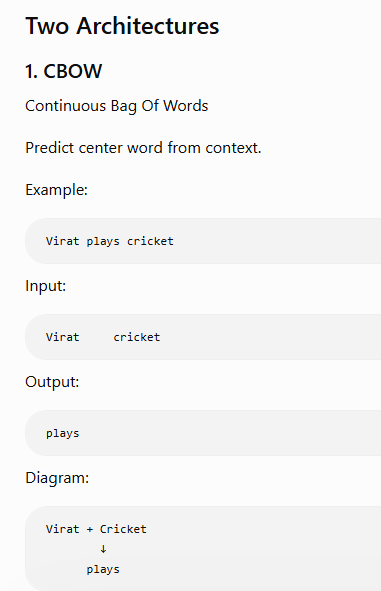

# 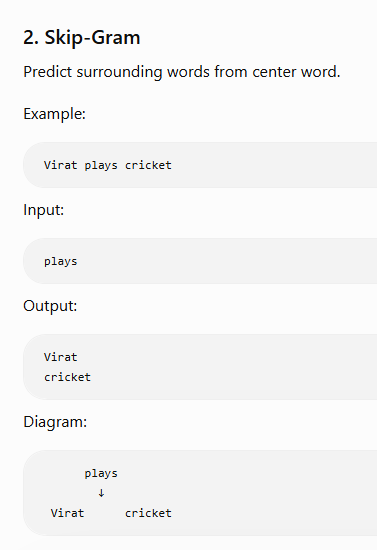

# 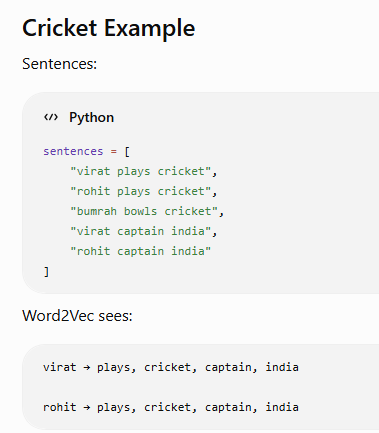

# 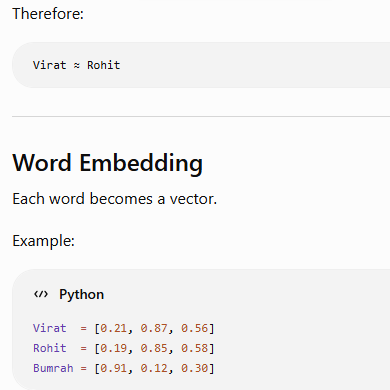

In [1]:
# pip install gensim

In [2]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [3]:
from gensim.models import Word2Vec

In [4]:
sentences = [
    ["virat","plays","cricket"],
    ["rohit","plays","cricket"],
    ["bumrah","bowls","cricket"],
    ["virat","captain","india"],
    ["rohit","captain","india"]
]

In [5]:
sentences

[['virat', 'plays', 'cricket'],
 ['rohit', 'plays', 'cricket'],
 ['bumrah', 'bowls', 'cricket'],
 ['virat', 'captain', 'india'],
 ['rohit', 'captain', 'india']]

In [6]:
model = Word2Vec(
    sentences,
    vector_size=5,
    window=2,
    min_count=1,
    workers=4
)

In [7]:
model

In [8]:
print(model.wv.index_to_key)

['cricket', 'india', 'captain', 'rohit', 'plays', 'virat', 'bowls', 'bumrah']


In [9]:
print(model.wv['virat'])

[-0.06810732 -0.01892803  0.11537147 -0.15043275 -0.07872207]


In [10]:
print(model.wv.most_similar("virat"))

[('bowls', 0.9323887825012207), ('india', 0.7741873860359192), ('rohit', 0.766875147819519), ('cricket', -0.0006994431605562568), ('bumrah', -0.13816477358341217), ('plays', -0.15349125862121582), ('captain', -0.6143277883529663)]


In [11]:
Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

| Parameter   | Meaning           |
| ----------- | ----------------- |
| vector_size | Embedding size    |
| window      | Context window    |
| min_count   | Ignore rare words |
| workers     | CPU threads       |


| Feature               | TF-IDF | Word2Vec |
| --------------------- | ------ | -------- |
| Counts Words          | ✅      | ❌        |
| Word Meaning          | ❌      | ✅        |
| Context               | ❌      | ✅        |
| Semantic Similarity   | ❌      | ✅        |
| Dense Vector          | ❌      | ✅        |
| Sparse Matrix         | ✅      | ❌        |
| Used in Deep Learning | ❌      | ✅        |


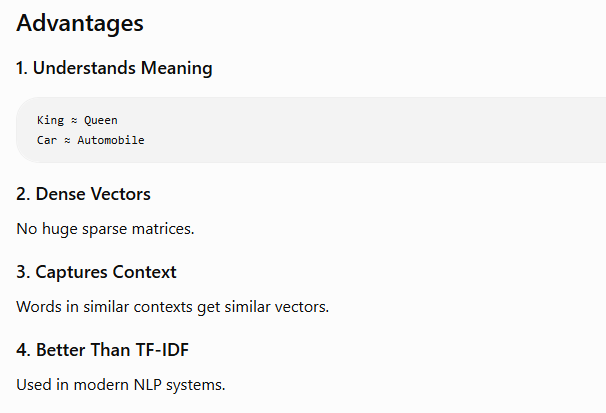

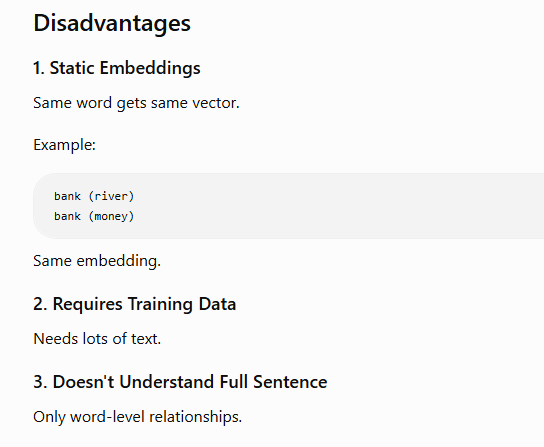

# 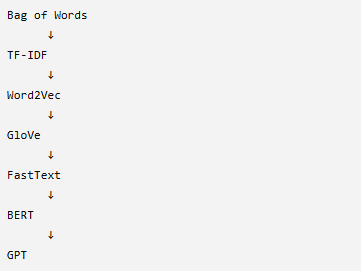

# Word2Vec is a neural network-based word embedding technique that converts words into dense numerical vectors while preserving semantic and contextual relationships between words. Similar words are represented by similar vectors in the embedding space

In [12]:
from gensim.models import Word2Vec
import pandas as pd

# Training Data
sentences = [
    ["munna", "likes", "cricket"],
    ["raunak", "likes", "cricket"],
    ["kuldeep", "likes", "football"],
    ["rohan", "plays", "football"],
    ["sohan", "likes", "cricket"],
    ["virat", "plays", "cricket"],
    ["rohit", "plays", "cricket"],
    ["virat", "captain", "india"],
    ["rohit", "captain", "india"],
]

# Train Model
model = Word2Vec(
    sentences,
    vector_size=10,  # Embedding Size
    window=2,        # Context Window
    min_count=1,     # Keep all words
    workers=4,
    sg=1             # 1 = Skip Gram, 0 = CBOW
)

# Vocabulary
print("=" * 50)
print("VOCABULARY")
print("=" * 50)

print(model.wv.index_to_key)

# Vector of a Word
print("\n")
print("=" * 50)
print("VECTOR OF VIRAT")
print("=" * 50)

print(model.wv["virat"])

# Similar Words
print("\n")
print("=" * 50)
print("SIMILAR WORDS TO VIRAT")
print("=" * 50)

print(model.wv.most_similar("virat"))

# Similarity Score
print("\n")
print("=" * 50)
print("SIMILARITY")
print("=" * 50)

print(
    "virat vs rohit =",
    model.wv.similarity("virat", "rohit")
)

# Create Embedding DataFrame
words = model.wv.index_to_key

vectors = []

for word in words:
    vectors.append(model.wv[word])

df = pd.DataFrame(vectors)

df.insert(0, "Word", words)

print("\n")
print("=" * 50)
print("WORD EMBEDDINGS")
print("=" * 50)

print(df)

# Save Embeddings
df.to_csv("word_embeddings.csv", index=False)

print("\nEmbeddings saved successfully!")

VOCABULARY
['cricket', 'likes', 'plays', 'india', 'captain', 'rohit', 'virat', 'football', 'sohan', 'rohan', 'kuldeep', 'raunak', 'munna']


VECTOR OF VIRAT
[-0.01577653  0.00321372 -0.0414063  -0.07682689 -0.01508008  0.02469795
 -0.00888027  0.05533662 -0.02742977  0.02260065]


SIMILAR WORDS TO VIRAT
[('captain', 0.6143981218338013), ('munna', 0.3862057030200958), ('football', 0.19734421372413635), ('raunak', 0.1153423935174942), ('rohit', -0.042645372450351715), ('plays', -0.08937528729438782), ('india', -0.11387497931718826), ('likes', -0.17998749017715454), ('cricket', -0.1897382289171219), ('rohan', -0.1986316740512848)]


SIMILARITY
virat vs rohit = -0.042645365


WORD EMBEDDINGS
        Word         0         1         2         3         4         5  \
0    cricket -0.005362  0.002364  0.051033  0.090093 -0.093029 -0.071168   
1      likes  0.073809 -0.015336 -0.045369  0.065544 -0.048604 -0.018161   
2      plays  0.073118  0.050703  0.067577  0.007629  0.063509 -0.034054   

In [13]:
model.wv["virat"]              # Get vector
model.wv.most_similar("virat") # Similar words
model.wv.similarity("virat","rohit") # Similarity score
model.wv.index_to_key          # Vocabulary
len(model.wv["virat"])         # Vector size

10

# 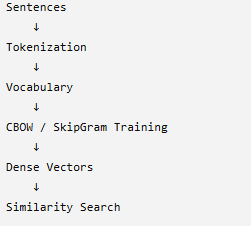

| Feature               | Bag of Words (BoW) | TF-IDF          | Word2Vec      | GloVe         | FastText      | BERT               | GPT Embeddings     |
| --------------------- | ------------------ | --------------- | ------------- | ------------- | ------------- | ------------------ | ------------------ |
| Year                  | Oldest             | After BoW       | 2013          | 2014          | 2016          | 2018               | 2018+              |
| Output                | Word Counts        | Weighted Counts | Dense Vectors | Dense Vectors | Dense Vectors | Contextual Vectors | Contextual Vectors |
| Understand Meaning    | ❌ No               | ❌ No            | ✅ Yes         | ✅ Yes         | ✅ Yes         | ✅ Yes              | ✅ Yes              |
| Understand Context    | ❌ No               | ❌ No            | ❌ No          | ❌ No          | ❌ No          | ✅ Yes              | ✅ Yes              |
| Word Order            | ❌ Ignored          | ❌ Ignored       | ❌ Ignored     | ❌ Ignored     | ❌ Ignored     | ✅ Considered       | ✅ Considered       |
| Sparse Matrix         | ✅ Yes              | ✅ Yes           | ❌ No          | ❌ No          | ❌ No          | ❌ No               | ❌ No               |
| Dense Embeddings      | ❌ No               | ❌ No            | ✅ Yes         | ✅ Yes         | ✅ Yes         | ✅ Yes              | ✅ Yes              |
| Handles Similar Words | ❌ No               | ❌ No            | ✅ Yes         | ✅ Yes         | ✅ Yes         | ✅ Yes              | ✅ Yes              |
| Handles Unknown Words | ❌ No               | ❌ No            | ❌ No          | ❌ No          | ✅ Yes         | ✅ Yes              | ✅ Yes              |
| Context-Aware         | ❌ No               | ❌ No            | ❌ No          | ❌ No          | ❌ No          | ✅ Yes              | ✅ Yes              |
| Text Generation       | ❌ No               | ❌ No            | ❌ No          | ❌ No          | ❌ No          | ❌ No               | ✅ Yes              |
| Used in Modern LLMs   | ❌ No               | ❌ No            | ❌ No          | ❌ No          | ❌ No          | Partial            | ✅ Yes              |


| Method   | Main Idea                    | Problem Solved                              |
| -------- | ---------------------------- | ------------------------------------------- |
| BoW      | Count words                  | Convert text to numbers                     |
| TF-IDF   | Weight important words       | Common words got too much importance in BoW |
| Word2Vec | Learn word meaning           | TF-IDF couldn't understand semantics        |
| GloVe    | Global + Local relationships | Better semantic relationships than Word2Vec |
| FastText | Subword embeddings           | Word2Vec failed on unknown words            |
| BERT     | Contextual embeddings        | Same word had one meaning in Word2Vec       |
| GPT      | Context + Generation         | BERT couldn't generate text                 |


| Model    | Output                               |
| -------- | ------------------------------------ |
| BoW      | Bank = Count                         |
| TF-IDF   | Bank = Weight                        |
| Word2Vec | One vector for Bank                  |
| GloVe    | One vector for Bank                  |
| FastText | One vector for Bank                  |
| BERT     | Different vector based on context    |
| GPT      | Different vector + can generate text |


| Model    | Understanding |
| -------- | ------------- |
| BoW      | Same          |
| TF-IDF   | Same          |
| Word2Vec | Same          |
| GloVe    | Same          |
| FastText | Same          |
| BERT     | Different     |
| GPT      | Different     |


| Method   | Biggest Problem                  |
| -------- | -------------------------------- |
| BoW      | No meaning                       |
| TF-IDF   | No meaning and no context        |
| Word2Vec | One word = one vector            |
| GloVe    | One word = one vector            |
| FastText | No context awareness             |
| BERT     | Cannot generate text effectively |
| GPT      | Computationally expensive        |


# 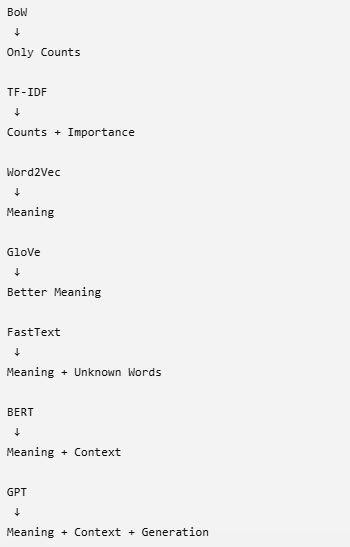

| Method   | One-Line Definition                        |
| -------- | ------------------------------------------ |
| BoW      | Counts word occurrences                    |
| TF-IDF   | Measures word importance                   |
| Word2Vec | Learns semantic word embeddings            |
| GloVe    | Learns global word embeddings              |
| FastText | Learns subword embeddings                  |
| BERT     | Context-aware bidirectional embeddings     |
| GPT      | Context-aware generative transformer model |


# BoW → TF-IDF → Word2Vec → GloVe → FastText → BERT → GPT
# Count → Importance → Meaning → Better Meaning → Unknown Words → Context → Generation